# Acquisition

*The converters into records: a task configured and clocked, its records read in a loop, scaled into a frame, and drawn live over the switches.*

**Abstract.** The board records sums of converter codes at a rate the task asks for and the loop manages, and a host reads them as `Record`s over one link. This notebook runs the whole path on the stand-in, and on a board with the knob flipped: the catalogue of what can be recorded, the rail that makes a reading a measurement, the clock tied to the host, a task of two then five channels, the record read back as sums, counts and means, a run scaled into a pandas frame through the calibration record, and a two-second window of phase currents and gate duties redrawn as they arrive. What it measures: the record period the loop managed against the rate asked for, the spread of `dt`, what the ring holds, and how far behind a reader is allowed to fall. What a reader takes to the bench: a record is a sum and a count, `dt` is measured and not configured, and a code column beside a scaled one is what arrived beside what it means.

## 1 Setup

In [1]:
SIMULATED = True          # False, and PORT, at the bench
PORT = 'COM4'

In [2]:
from coaxial import Coaxial63100

device = Coaxial63100(port=PORT, device=SIMULATED).open()
print(device)

<Coaxial63100 Simulated SIMULATED>


## 2 What the board can record

`daq.catalogue()` is the board's own list, each row saying its kind and whether `configure()` may ask for it. AFE_ON powers the ADC reference: with it off every channel reads exact mid-scale and the NTC exactly 25.00 C (invariant 9), so `enable()` takes this session's reference on the rail before anything is believed, and `close()` releases it.

In [3]:
daq = device.daq
daq.open()
for row in daq.catalogue():
    print('%-16s %-8s %-4s %-10s selectable=%s'
          % (row['name'], row['kind'], row['direction'], row['unit'],
             row['selectable']))
daq.enable()
print(device.afe.state())

Phase U          analog   in   mA         selectable=True
Phase V          analog   in   mA         selectable=True
Phase W          analog   in   mA         selectable=True
Clevel           analog   in   None       selectable=True
NTC              analog   in   centi-degC selectable=True
DC bus           analog   in   mV         selectable=True
Cinj             analog   in   None       selectable=True
+5V              analog   in   mV         selectable=True
Vgate            analog   in   mV         selectable=True
MCU die          analog   in   centi-degC selectable=True
AFE_ON           digital  out  duty       selectable=True
UART5_TERM       digital  out  duty       selectable=True
KEEPALIVE        digital  out  duty       selectable=True
orientation      sensor   in   quaternion selectable=True
acceleration     sensor   in   m/s^2      selectable=True
rotation rate    sensor   in   rad/s      selectable=True
magnetic field   sensor   in   uT         selectable=True
shaft angle   

## 3 The clock

The board counts cycles, not time. `set_time_from_pc` ties the counter to the host's clock; `reference='utc'` measures that clock against NTP over the same window and takes out its offset and its rate, since a host clock is not a reference either.

In [4]:
sync = device.set_time_from_pc(reference='pc')
print(sync)

<Sync 474.980631 MHz (-40.8 ppm vs pc, floor 0.2 ppm), reference +/- 1 us>


## 4 A task, read in a loop

`start()` puts a reader thread on the link, and it is the only thing that touches the transport while it lives. Every `read(-1)` answers its own backlog: the first record blocks, the rest come with it.

In [5]:
import time

layout = daq.configure('phaseU', 'NTC', sample_rate=50)
print(daq.channel_names())
print(layout)
daq.start()
records = []
for _ in range(5):
    records.extend(daq.read(-1))
    time.sleep(0.2)
daq.stop()
for r in records[:8]:
    print('%.3f  dt %-7s %s' % (r.start_time, '%.4f' % r.dt if r.dt is not None else 'none',
                                 [(s.name, round(s.value, 1)) for s in r.samples]))
print('records:', len(records))
shape = daq.state()
held = daq.buffered
print(shape)
print(held)

['Phase U', 'NTC']
{'stride': 23, 'fields': [{'channel': 0, 'unit': 'mA', 'differential': True, 'signal': 'Phase U'}, {'channel': 4, 'unit': 'centi-degC', 'differential': False, 'signal': 'NTC'}], 'pins': [{'signal': 'AFE_ON', 'direction': 'out'}, {'signal': 'nFAULT/TIM1_BKIN', 'direction': 'in'}, {'signal': 'KEEPALIVE', 'direction': 'out'}, {'signal': 'TIM1_CH1N/PWMUL', 'direction': 'out'}, {'signal': 'TIM1_CH1/PWMUH', 'direction': 'out'}, {'signal': 'TIM1_CH2N/PWMVL', 'direction': 'out'}, {'signal': 'TIM1_CH2/PWMVH', 'direction': 'out'}, {'signal': 'TIM1_CH3N/PWMWL', 'direction': 'out'}, {'signal': 'TIM1_CH3/PWMWH', 'direction': 'out'}], 'sensors': []}


1790235393.864  dt none    [('Phase U', 1399.8), ('NTC', 35043.7)]
1790235393.884  dt 0.0200  [('Phase U', 1399.5), ('NTC', 35038.5)]
1790235393.904  dt 0.0200  [('Phase U', 1395.4), ('NTC', 35035.9)]
1790235393.924  dt 0.0200  [('Phase U', 1400.0), ('NTC', 35038.4)]
1790235393.944  dt 0.0200  [('Phase U', 1403.1), ('NTC', 35037.4)]
1790235393.964  dt 0.0200  [('Phase U', 1400.8), ('NTC', 35030.1)]
1790235393.984  dt 0.0200  [('Phase U', 1403.6), ('NTC', 35025.5)]
1790235394.004  dt 0.0200  [('Phase U', 1390.7), ('NTC', 35021.9)]
records: 38
{'running': False, 'done': False, 'lost_power': False, 'stride': 23, 'fields': 2, 'available': 0, 'produced': 52, 'dropped': 0, 'capacity': 19945, 'worst': 0, 'rung': 0, 'rungs': 0, 'rung_changes': 0, 'max_rate_hz': 375, 'sensors_available': 31, 'sensors_supported': True, 'channels': 17, 'clock': 'software', 'sample_time': 0, 'decimate': 1, 'accumulate': 0, 'records': 0, 'digital': True, 'interval_us': 20000, 'sensors': 0}
{'host': 0, 'peak': 0, 'd

A `Record` is a dict underneath: `r['NTC']` is the SUM over `r.count` readings, `r.value('NTC')` that channel's mean and `r.sample('NTC')` the struct behind it. `daq.series` and `daq.columns` are the two helpers around a whole run.

In [6]:
r = records[0]
print('sum   ', r['NTC'])
print('count ', r.count, ' (r["samples"] is the same number:', r['samples'], ')')
print('mean  ', r.value('NTC'))
print('sample', r.sample('NTC'))
print('names ', r.channel_name)
print('pins  ', r.digital)
cols = daq.columns(records)
print(sorted(cols))
ntc = daq.series(records, 'NTC')
seconds = daq.series(records, 'time')
print('%.1f s of NTC, first %.1f last %.1f' % (seconds[-1] - seconds[0], ntc[0], ntc[-1]))

sum    4625772.0
count  132  (r["samples"] is the same number: 132 )
mean   35043.72727272727
sample <NTC 35043.7 raw -> centi-degC>
names  ('Phase U', 'NTC')
pins   {'AFE_ON': 1.0, 'nFAULT/TIM1_BKIN': 1.0, 'KEEPALIVE': 0.497990684703118, 'TIM1_CH1N/PWMUL': 0.0, 'TIM1_CH1/PWMUH': 0.0, 'TIM1_CH2N/PWMVL': 0.0, 'TIM1_CH2/PWMVH': 0.0, 'TIM1_CH3N/PWMWL': 0.0, 'TIM1_CH3/PWMWH': 0.0}
['AFE_ON', 'KEEPALIVE', 'NTC', 'Phase U', 'TIM1_CH1/PWMUH', 'TIM1_CH1N/PWMUL', 'TIM1_CH2/PWMVH', 'TIM1_CH2N/PWMVL', 'TIM1_CH3/PWMWH', 'TIM1_CH3N/PWMWL', 'dt', 'nFAULT/TIM1_BKIN', 'time']
0.7 s of NTC, first 35043.7 last 35023.2


## 5 A run into a frame, scaled by the record

`frame(scaled=True)` adds one column per channel in real units beside the codes, through the board's own converters and the channel trims in its calibration record (invariant 7). `stored` says whether that record was ever written or is the schematic's arithmetic; an uncalibrated board answers an empty record and every converter falls back to the compiled-in constant, which is what `name` says.

In [7]:
daq.configure('phaseU', 'phaseV', 'phaseW', 'DC bus', 'NTC', sample_rate=100)
daq.start()
run = daq.read(300)
daq.stop()
print(len(run), 'records;', daq.channel_names(run[0]))
cal = device.calibration.read()
print('record stored:', cal['stored'], ' version:', cal['version'],
      ' params held:', len(cal['params']))
for name, params in sorted(device.analog.scaling().items()):
    print('%-8s %s' % (name, params.name))
print('channel trims:', [(c['index'], c['offset_raw'], c['gain_ppm'])
                         for c in cal['channels'][:3]])

300 records; ['Phase U', 'Phase V', 'Phase W', 'NTC', 'DC bus']
record stored: False  version: 0  params held: 0
dcbus    compiled-in fallback, the board sent no record
ntc      compiled-in fallback, the board sent no record
phase    compiled-in fallback, the board sent no record
rail5    compiled-in fallback, the board sent no record
vgate    compiled-in fallback, the board sent no record
channel trims: [(0, 0, 0), (1, 0, 0), (2, 0, 0)]


In [8]:
df = daq.frame(run, index='elapsed', scaled=True)
df.head()

,Phase U,Phase V,Phase W,NTC,DC bus,AFE_ON,nFAULT/TIM1_BKIN,KEEPALIVE,TIM1_CH1N/PWMUL,TIM1_CH1/PWMUH,...,TIM1_CH2/PWMVH,TIM1_CH3N/PWMWL,TIM1_CH3/PWMWH,time,dt,Phase U (A),Phase V (A),Phase W (A),NTC (C),DC bus (V)
elapsed,,,,,,,,,,,,,,,,,,,,,
0.000000,1400.769231,-8030.846154,354.115385,35084.500000,19205.384615,1.0,1.0,0.475025,0.0,0.0,...,0.0,0.0,0.0,1.790235e+09,NaN,8.867173,-50.836999,2.241627,28.771812,22.901929
0.010000,1398.961538,-8029.692308,357.153846,35080.769231,19203.038462,1.0,1.0,0.499977,0.0,0.0,...,0.0,0.0,0.0,1.790235e+09,0.01,8.855730,-50.829695,2.260861,28.765640,22.899131
0.020001,1405.615385,-8024.846154,353.346154,35082.961538,19220.038462,1.0,1.0,0.491500,0.0,0.0,...,0.0,0.0,0.0,1.790235e+09,0.01,8.897850,-50.799018,2.236758,28.769267,22.919403
0.030001,1402.500000,-8035.807692,362.576923,35084.692308,19222.153846,1.0,1.0,0.500265,0.0,0.0,...,0.0,0.0,0.0,1.790235e+09,0.01,8.878129,-50.868406,2.295191,28.772130,22.921926
0.040002,1406.461538,-8042.500000,364.423077,35104.230769,19236.615385,1.0,1.0,0.486216,0.0,0.0,...,0.0,0.0,0.0,1.790235e+09,0.01,8.903207,-50.910770,2.306877,28.804458,22.939171


In [9]:
df.describe().round(3)

,Phase U,Phase V,Phase W,NTC,DC bus,AFE_ON,nFAULT/TIM1_BKIN,KEEPALIVE,TIM1_CH1N/PWMUL,TIM1_CH1/PWMUH,...,TIM1_CH2/PWMVH,TIM1_CH3N/PWMWL,TIM1_CH3/PWMWH,time,dt,Phase U (A),Phase V (A),Phase W (A),NTC (C),DC bus (V)
count,300.000,300.000,300.000,300.000,300.000,300.0,300.0,300.000,300.0,300.0,...,300.0,300.0,300.0,3.000000e+02,299.00,300.000,300.000,300.000,300.000,300.000
mean,1400.018,-8029.543,360.843,36133.921,20823.257,1.0,1.0,0.500,0.0,0.0,...,0.0,0.0,0.0,1.790235e+09,0.01,8.862,-50.829,2.284,30.532,24.831
std,7.029,6.691,6.711,784.131,940.827,0.0,0.0,0.021,0.0,0.0,...,0.0,0.0,0.0,8.680000e-01,0.00,0.044,0.042,0.042,1.324,1.122
min,1381.577,-8048.423,342.538,35080.769,19203.038,1.0,1.0,0.449,0.0,0.0,...,0.0,0.0,0.0,1.790235e+09,0.01,8.746,-50.948,2.168,28.766,22.899
25%,1395.288,-8034.260,355.990,35445.529,20046.163,1.0,1.0,0.485,0.0,0.0,...,0.0,0.0,0.0,1.790235e+09,0.01,8.832,-50.859,2.253,29.371,23.905
50%,1400.250,-8029.192,360.885,35989.519,20825.519,1.0,1.0,0.500,0.0,0.0,...,0.0,0.0,0.0,1.790235e+09,0.01,8.864,-50.827,2.284,30.280,24.834
75%,1404.356,-8024.808,365.308,36750.452,21621.721,1.0,1.0,0.515,0.0,0.0,...,0.0,0.0,0.0,1.790235e+09,0.01,8.890,-50.799,2.312,31.566,25.783
max,1420.846,-8010.423,379.962,37741.038,22435.846,1.0,1.0,0.561,0.0,0.0,...,0.0,0.0,0.0,1.790235e+09,0.01,8.994,-50.708,2.405,33.268,26.754


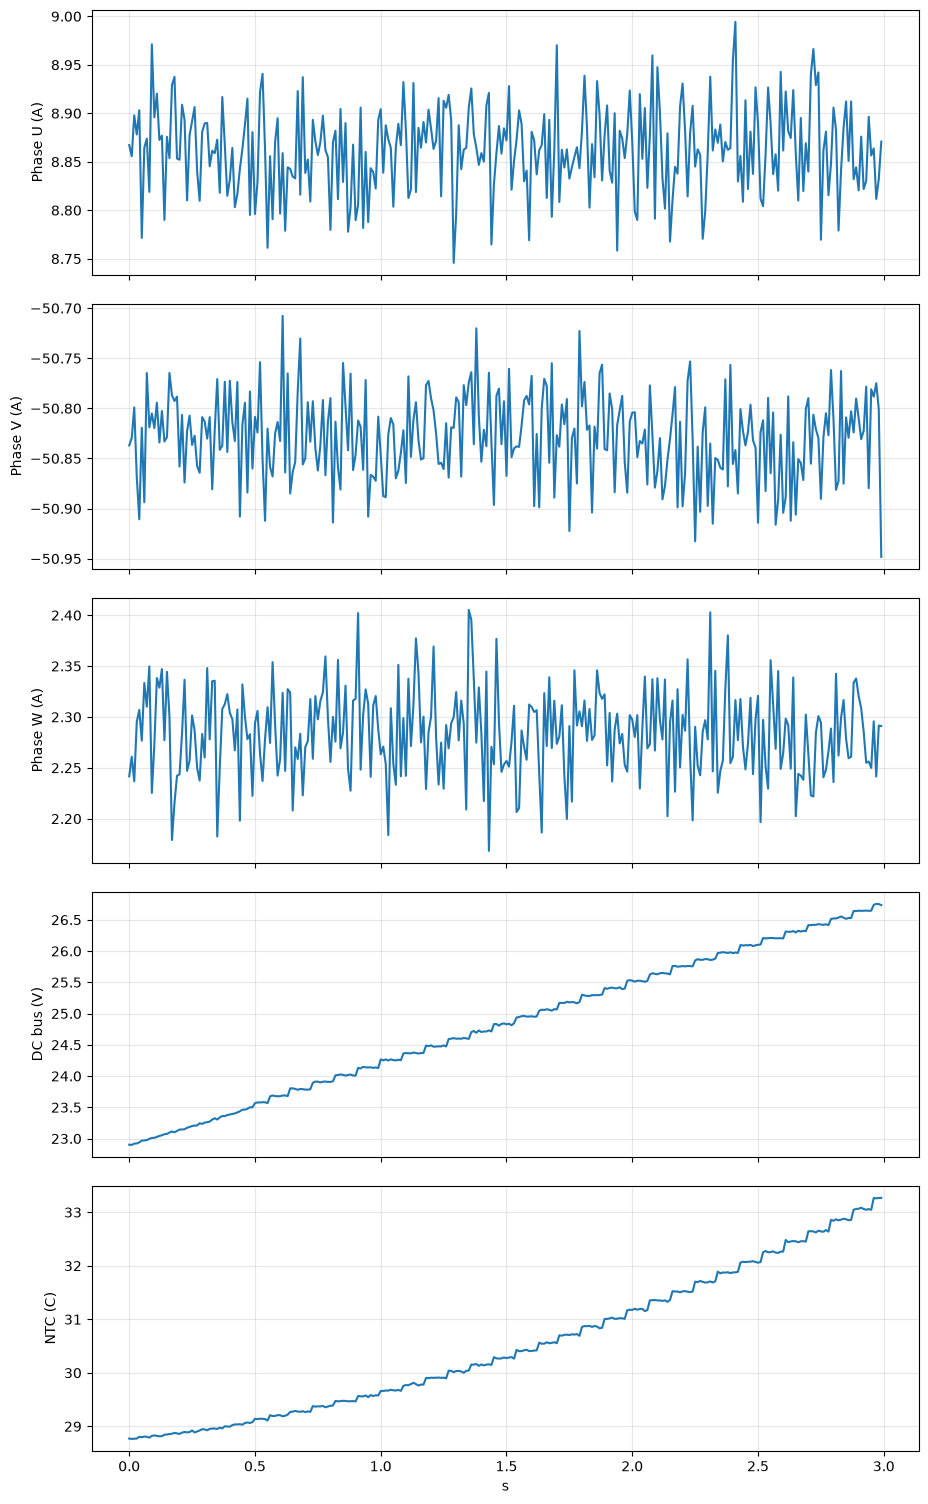

In [10]:
from coaxial.draw.figures import figure, show

units = [c for c in df.columns if c.endswith('(A)')]
shown = units + ['DC bus (V)', 'NTC (C)']
fig, panels = figure(rows=len(shown), sharex=True)
for panel, column in zip(panels, shown):
    panel.plot(df.index, df[column])
    panel.set_ylabel(column)
panels[-1].set_xlabel('s')
show(fig)

The codes stay in the frame under the board's own channel names, so a tare or a span can be checked against what arrived.

In [11]:
print(df[['Phase U', 'Phase U (A)', 'NTC', 'NTC (C)']].iloc[:3])

              Phase U  Phase U (A)           NTC    NTC (C)
elapsed                                                    
0.000000  1400.769231     8.867173  35084.500000  28.771812
0.010000  1398.961538     8.855730  35080.769231  28.765640
0.020001  1405.615385     8.897850  35082.961538  28.769267


## 6 Currents over the switches, live

The pins ride the same records as the analog fields, so every point on both is one window. The phase sense is zeroed with the stage down - a tare stores what the channels read now as their zero - and then the drive holds a current vector turning at 3.5 Hz electrical on the model: three currents 120 degrees apart, and the six gates modulating about half. Fifty records a second is fourteen points per electrical turn. `frames()` yields the last `window` seconds each time records arrive, indexed on seconds before now.

In [12]:
import math

daq.configure('phaseU', 'phaseV', 'phaseW', digital=True, sample_rate=50)
print(daq.channel_names())
print(device.calibration.tare('phaseU', 'phaseV', 'phaseW'))
drive = device.drive
drive.configure(source='model')
device.gates.on(bypass_sto=True, ignore_interlock=True)
drive.write(id_ref=4.0, iq_ref=0.0, theta=0.0, omega_target=2 * math.pi * 3.5)
drive.hold()

['Phase U', 'Phase V', 'Phase W']
{'Phase U': 1431, 'Phase V': -8044, 'Phase W': 361}


True

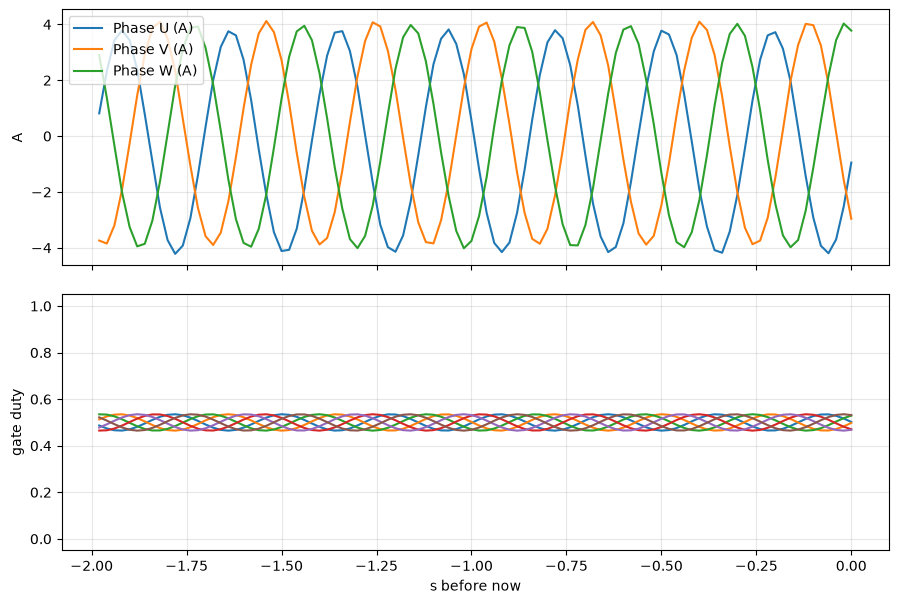

38 frames drawn; {'host': 2, 'peak': 8, 'dropped': 0, 'backlog': 0, 'reads': 137, 'records': 304, 'rate': 49.93010493300147, 'lost': 0, 'cursor': 0}
296 records held, 5.9 s back


In [13]:
from IPython.display import clear_output

daq.start()
frames = 0
for window in daq.frames(window=2.0, buffer=6.0, seconds=6.0, scaled=True):
    frames += 1
    clear_output(wait=True)
    fig, (top, bottom) = figure(rows=2, sharex=True)
    for column in (c for c in window.columns if c.endswith('(A)')):
        top.plot(window.index, window[column], label=column)
    top.set_ylabel('A')
    top.legend(loc='upper left')
    for column in (c for c in window.columns if c.startswith('TIM1_CH')):
        bottom.plot(window.index, window[column])
    bottom.set_ylabel('gate duty')
    bottom.set_ylim(-0.05, 1.05)
    bottom.set_xlabel('s before now')
    show(fig)
live = daq.buffered
daq.stop()
drive.off()
device.gates.off()
drive.configure(source='adc')
whole = daq.history(scaled=True)
print(frames, 'frames drawn;', live)
print(len(whole), 'records held,', round(-whole.index.min(), 2), 's back')

In [14]:
device.close()
print(device)

<Coaxial63100 Simulated SIMULATED>


## 7 Conclusions

In [15]:
spans = [r.dt for r in records if r.dt]
counts = [r.count for r in records]
codes = [c for c in df.columns if not c.endswith(')')]
scaled = [c for c in df.columns if c.endswith(')')]
print('1. records          %d at 50/s asked, %.2f s of covered time' % (len(records), sum(spans)))
print('2. record period    %.4f s mean = %.1f /s; dt spread %.4f to %.4f s'
      % (sum(spans) / len(spans), len(spans) / sum(spans), min(spans), max(spans)))
print('3. readings summed  %d to %d per record' % (min(counts), max(counts)))
print('4. stride           %d bytes, %d analog fields; the ring holds %d records'
      % (shape['stride'], shape['fields'], shape['capacity']))
print('5. dropped          %d, host queue peak %d' % (shape['dropped'], held['peak']))
print('6. frame            %d records, %d code columns, %d scaled columns'
      % (len(df), len(codes), len(scaled)))
for name in ('Phase U', 'DC bus', 'NTC'):
    unit = [c for c in scaled if c.startswith(name)][0]
    span = df[unit].max() - df[unit].min()
    print('   %-8s codes %8.1f +/- %6.1f   %-12s %8.3f +/- %.3f  span %.3f'
          % (name, df[name].mean(), df[name].std(), unit, df[unit].mean(),
             df[unit].std(), span))
print('7. live             %d frames in 6 s = %.1f /s; %d records %.2f s deep; '
      'reader %d reads, %.1f records/s; queue peak %d, dropped %d, board backlog %s'
      % (frames, frames / 6.0, len(whole), -whole.index.min(), live['reads'],
         live['rate'], live['peak'], live['dropped'], live['backlog']))

1. records          38 at 50/s asked, 0.74 s of covered time
2. record period    0.0200 s mean = 50.0 /s; dt spread 0.0200 to 0.0200 s
3. readings summed  132 to 132 per record
4. stride           23 bytes, 2 analog fields; the ring holds 19945 records
5. dropped          0, host queue peak 0
6. frame            300 records, 16 code columns, 5 scaled columns
   Phase U  codes   1400.0 +/-    7.0   Phase U (A)     8.862 +/- 0.044  span 0.249
   DC bus   codes  20823.3 +/-  940.8   DC bus (V)     24.831 +/- 1.122  span 3.855
   NTC      codes  36133.9 +/-  784.1   NTC (C)        30.532 +/- 1.324  span 4.502
7. live             38 frames in 6 s = 6.3 /s; 296 records 5.90 s deep; reader 137 reads, 49.9 records/s; queue peak 8, dropped 0, board backlog 0


`dt` is measured, not configured: it is the gap to the next record's timestamp within the block that carried it, because what the task was asked for and what the loop managed are different numbers - which is why the board sends a count with every sum. It is per block because the stamps are raw CYCCNT and that counter wraps every 9.04 s at 475 MHz; the acquisition unwraps each block it receives, so an index that runs longer than that stays monotonic. `dropped` is what the ring had no room for; a reader thread that keeps up leaves it at zero.

A code column is what arrived; the column beside it is what it means. The conversion is the board's own (invariant 7): the scaling lives in the calibration record, so `frame(scaled=True)` asks `board.analog.scaling()` rather than holding a constant, then applies that channel's offset and gain trim. Both columns stay, because what arrived and what it means are two things. With an empty record every converter falls back to the compiled-in constant and says so in `name`. `calibration.span(index, reference)` writes a gain trim against an instrument, taking the reference in the channel's own unit - mA for a phase, mV for the DC link; the DC link's stands at -32 418 ppm (FINDINGS). That divider is 49.9k/2.2k: 78.15 V full scale on a 63 V rating, 24 % of headroom so an over-rating transient is recorded rather than clipped (invariant 11).

Live, the reader thread is the only thing on the transport, so a redraw in the loop never sits between two round trips, and every read answers its own backlog in the same transaction. `frames()` yields what is on screen and keeps `buffer` seconds behind it as records, so nothing is concatenated and nothing grows; the index is seconds before now, newest at 0, so the axis stands still while the data moves through it. A ring is finite: a reader that falls far enough behind for the writer to lap it loses records and is told how many in `buffered['lost']` - a terminal that stopped drawing for six seconds once overflowed a 16 K ring, 334 records (FINDINGS).

**At the bench.** Flip `SIMULATED` and name the port. Run the first three sections before trusting a number: the catalogue says what this firmware records, `afe.state()` says the reference rail is up, and the sync says how far the host clock sat from NTP. Then compare conclusion 2 against the rate asked for - the loop's own period is what the board managed, and a board under a switching run manages less. Before a scaled frame means amperes, read `stored` and `version` in section 5: an empty record is the schematic's arithmetic, and `calibration.span` against a meter is what turns it into a measurement. The stand-in cannot show a lapped ring or a reader falling behind a real link; `buffered['lost']` on a board is where that shows.

## References

* `host/coaxial/rig.py` - the front door: `daq`, `set_time_from_pc`, `frame`, `frames`, `history`
* `host/coaxial/acquire/record.py` - a `Record`: the sum, the count, the mean, the struct behind a sample
* `host/coaxial/simulated/acquire/` - the stand-in this ran on, paced to real time like a board
* `daq/src/daq.c` - the engine on the board: the ring, the window, the ladder
* `docs/PROTOCOL.md` - device 6, the task and the record on the wire
* `host/tests/test_daq_api.py` - the front door pinned: naming, reading, the record shape, the buffers